Kacper  Kaszuba

# Zadanie 1. Role węzłów w sieci

In [96]:
# import bibliotek
import networkx as nx
from networkx.algorithms.community import girvan_newman, louvain_communities, label_propagation_communities, asyn_fluidc
from networkx.algorithms.community.quality import modularity

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import pandas as pd
import numpy as np
import seaborn as sns

import random
from pprint import pprint



Graph named "Zachary's Karate Club" with 34 nodes and 78 edges


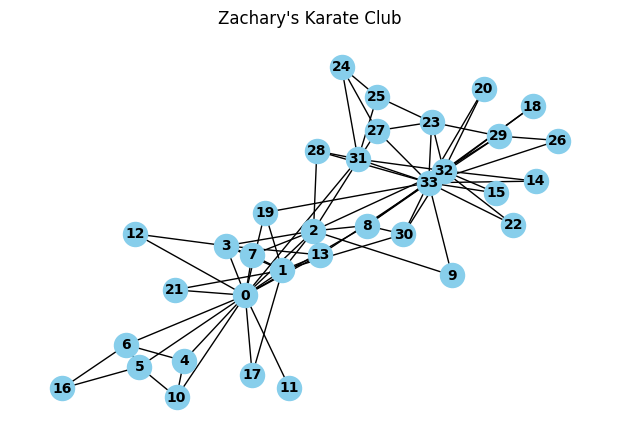

In [97]:
# 1
G = nx.karate_club_graph()
print(G)

# Draw the graph
plt.figure(figsize=(6, 4))
nx.draw(G, with_labels=True, node_color='skyblue', font_size=10, font_weight='bold')
plt.title("Zachary's Karate Club")
plt.show()

### 2. Wybrane miary  to:

- degree
- clustering
- closeness
- eigenvector centrality
- betweenness
- pagerank


In [98]:

df = pd.DataFrame({
    'degree': dict(G.degree()),
    'betweenness': nx.betweenness_centrality(G),
    'closeness': nx.closeness_centrality(G),
    'clustering': nx.clustering(G),
    'pagerank': nx.pagerank(G),
    'eigenvector centrality': nx.eigenvector_centrality(G)
})

df.index.name = 'node'
df = df.sort_values('betweenness', ascending=False)
df

,degree,betweenness,closeness,clustering,pagerank,eigenvector centrality
node,,,,,,
0,16,0.437635,0.568966,0.150000,0.088508,0.355483
33,17,0.304075,0.550000,0.110294,0.096980,0.373371
32,12,0.145247,0.515625,0.196970,0.075926,0.308651
2,10,0.143657,0.559322,0.244444,0.062767,0.317189
31,6,0.138276,0.540984,0.200000,0.041985,0.191036
8,5,0.055927,0.515625,0.500000,0.033382,0.227405
1,9,0.053937,0.485294,0.333333,0.057415,0.265954
13,5,0.045863,0.515625,0.600000,0.033474,0.226470
19,3,0.032475,0.500000,0.333333,0.013078,0.147911


###   3. Cechy poszczególnych ról:
1. Liderzy:
- Ma najwięcej kontaktów np >12  lub max 4 liderów `degree`
- wysoka wartość `eigenvector centrality`
- Duże `PageRank`

2. Pośrednicy:
- Mają bezpośredni kontakt z liderami
- mają sporo kontaków np > 6
- Duża wartość `betwennes`  

3. Węzły lokalnie osadzone:
- Poasda mocno połączone kontakty
- "Wszyscy sie znają"
- współczynnik  `degree` umiarkwoany
- silnie osadzone w lokalnej grupie
- `clustering` ma ważną role

4. Węzły peryferyjne:
- Mało kontaktów
- Obrzerza grafu
- Mały  wpływ na  klub
- małe `Closeness`

In [99]:
liderzy_df = df[(df['degree'] >= 12) & (df['closeness'] >  0.4) & (df['eigenvector centrality'] > 0.3) & (df['pagerank'] > 0.07) ].sort_values('pagerank', ascending=False).head(4)
liderzy_list = liderzy_df.index.tolist()
liderzy_df

,degree,betweenness,closeness,clustering,pagerank,eigenvector centrality
node,,,,,,
33,17,0.304075,0.550000,0.110294,0.096980,0.373371
0,16,0.437635,0.568966,0.150000,0.088508,0.355483
32,12,0.145247,0.515625,0.196970,0.075926,0.308651


In [100]:
# napewno musimy dodać waronek pośrednik != lider
posrednicy_df = df[(df['degree'] >= 6 ) & (df['betweenness'] > 0.04) & (~df.index.isin(liderzy_list))].sort_values('pagerank', ascending=True).head(6)
#  = posrednicy_df.index.tolist()

posrednicy_list = []
for node in posrednicy_df.index:
  sasiedzi = list(G.neighbors(node))
  ma_kontakt = any(sasiad in liderzy_list for sasiad in sasiedzi)
  if ma_kontakt:
    posrednicy_list.append(node)
    print(f"Węzły {node} ma kontakt z ldierem dzięki temu jest bardzo dobrym pośrednikiem")

posrednicy_df_final = df[df.index.isin(posrednicy_list)]
posrednicy_df_final


Węzły 31 ma kontakt z ldierem dzięki temu jest bardzo dobrym pośrednikiem
Węzły 1 ma kontakt z ldierem dzięki temu jest bardzo dobrym pośrednikiem
Węzły 2 ma kontakt z ldierem dzięki temu jest bardzo dobrym pośrednikiem


,degree,betweenness,closeness,clustering,pagerank,eigenvector centrality
node,,,,,,
2,10,0.143657,0.559322,0.244444,0.062767,0.317189
31,6,0.138276,0.540984,0.200000,0.041985,0.191036
1,9,0.053937,0.485294,0.333333,0.057415,0.265954


In [101]:
wezly_lokalne  = df[(df['degree'] < 7) & (df['degree'] > 3)].sort_values('clustering', ascending=False).head(8)
wezly_lokalne_list = wezly_lokalne.index.tolist()
wezly_lokalne

,degree,betweenness,closeness,clustering,pagerank,eigenvector centrality
node,,,,,,
7,4,0.000000,0.440000,1.000000,0.026465,0.170955
3,6,0.011909,0.464789,0.666667,0.037212,0.211174
29,4,0.002922,0.383721,0.666667,0.028272,0.134965
13,5,0.045863,0.515625,0.600000,0.033474,0.226470
8,5,0.055927,0.515625,0.500000,0.033382,0.227405
6,4,0.029987,0.383721,0.500000,0.031529,0.079481
5,4,0.029987,0.383721,0.500000,0.033810,0.079481
30,4,0.014412,0.458333,0.500000,0.023032,0.174760


In [102]:
wezly_peryferyjne = df[(df['closeness'] < 0.4) & (df['degree'] <= 3)]
wezly_peryferyjne_list = wezly_peryferyjne.index.tolist()
wezly_peryferyjne


,degree,betweenness,closeness,clustering,pagerank,eigenvector centrality
node,,,,,,
25,3,0.003840,0.375000,0.333333,0.028673,0.059208
24,3,0.002210,0.375000,0.333333,0.016634,0.057054
4,3,0.000631,0.379310,0.666667,0.020504,0.075966
10,3,0.000631,0.379310,0.666667,0.020689,0.075966
12,2,0.000000,0.370787,1.000000,0.011475,0.084252
11,1,0.000000,0.366667,0.000000,0.009786,0.052854
14,2,0.000000,0.370787,1.000000,0.012942,0.101406
17,2,0.000000,0.375000,1.000000,0.009677,0.092397
16,2,0.000000,0.284483,1.000000,0.016755,0.023635


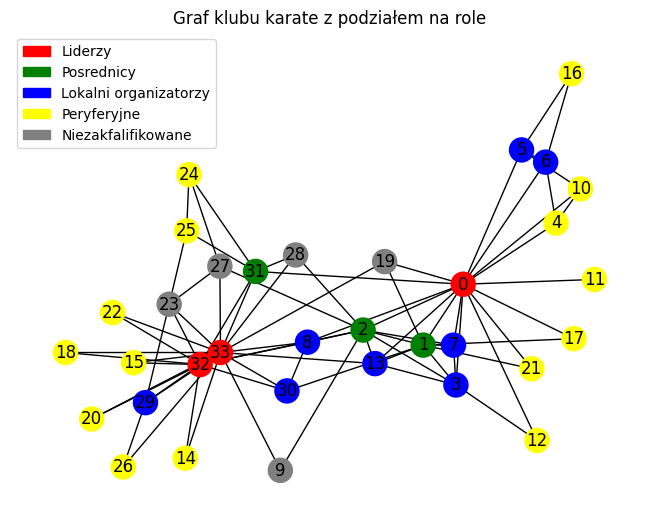

In [103]:
node_colors = []
for node in G.nodes():
  if node in liderzy_list:
    node_colors.append('red')
  elif node in posrednicy_list:
    node_colors.append('green')
  elif node in wezly_lokalne_list:
    node_colors.append('blue')
  elif node in wezly_peryferyjne_list:
    node_colors.append('yellow')
  else:
    node_colors.append('grey')

liderzy_leg = mpatches.Patch(color='red', label='Liderzy')
posrednicy_leg = mpatches.Patch(color='green', label='Posrednicy')
lokalni_leg = mpatches.Patch(color='blue', label='Lokalni organizatorzy')
peryferyjne_leg = mpatches.Patch(color='yellow', label='Peryferyjne')
niezakfalifikowane_leg = mpatches.Patch(color='grey', label='Niezakfalifikowane')

nx.draw(G,
        with_labels=True,
        node_color=node_colors)
plt.legend(handles=[liderzy_leg, posrednicy_leg, lokalni_leg, peryferyjne_leg, niezakfalifikowane_leg])
plt.title("Graf klubu karate z podziałem na role")
plt.show()

## Notatki i wnioski do Zadanie 1

### Wybrane miary:
- degree
- clustering
- closeness
- eigenvector centrality
- betweenness
- pagerank

### Zaproponowane role i najważniejsze cechy:
1. Liderzy:

a. Cechy
- Ma najwięcej kontaktów, np. >12, może być max 4 liderów
- Wysokie `degree`
- wysoka wartość `eigenvector centrality`
- Duże `PageRank`

b. Przykładowe węzły:
- nr 0, 32, 33

c. Uzasadnienie:
- Bardzo wysokie `degree`
- wysokie wskaźniki `eigenvector centrality`, `PageRank`
- numery 0 i 33 są największymi liderami (`degree` na poziomie 16 i 17, gdzie następne ma 12)

2. Pośrednicy:

a. Cechy:
- Mają bezpośredni kontakt z liderami
- mają sporo kontaktów, np. > 6
- Duża wartość `betweenness`  
- Nie mogą być liderami

b. Przykładowe węzły:
- nr 1, 2, 31

c. Uzasadnienie:
- Sporo pośredników może być "przefiltrowane" przed dodaniem przeze mnie warunku, że pośrednik musi "znać" lidera oraz nim nie być.
- Bez tego byłoby ich więcej
- Mają oni spore `eigenvector centrality`, `degree` jest większe niż 6, oraz wskaźnik `betweenness` jest duży.

3. Węzły lokalnie osadzone:

a. Cechy
- Posiada mocno połączone kontakty
- "Wszyscy się znają"
- współczynnik `degree` umiarkowany
- silnie osadzone w lokalnej grupie
- `clustering` ma ważną rolę
- Max 8

b. Przykładowe węzły:
- nr 7, 3, 13

c. Uzasadnienie:
- Znają się nawzajem, o czym świadczy duża wartość wskaźnika `clustering`
- Wartość `degree` znajduje się w przedziale (3, 7)

4. Węzły peryferyjne:

a. Cechy:
- Mało kontaktów
- Obrzeża grafu
- Mały wpływ na klub
- `degree` <= 3
- małe `closeness` (mniejsze niż 0.04)

b. Przykładowe węzły:
- nr 14, 20, 11

c. Uzasadnienie:
- Znają 1 lub 2 osoby, `degree` < 3
- Parametr `closeness` na niskim poziomie < 0.4
- Mały wpływ na klub

5. Niezakwalifikowani:

a. Cechy
- nie należą do żadnej grupy
- Przez to, że nadaję wartości ramowe, jest szansa, że tacy się pojawią

b. Przykładowe węzły:
- nr 19, 28, 9

c. Uzasadnienie:
- Znajdują się "poza" podanymi ramami, np. 28 ma `degree` 3, a `closeness` na poziomie 0.45
- nr 9 ma `degree`: 2, ale `closeness` na poziomie 0.43, więc prawie się kwalifikuje do peryferyjnych

### Najważniejsze obserwacje:
1. Odp. na "Czy węzeł o wysokim stopniu zawsze jest liderem?". Liderów jest tylko 3, kolejny "pretendent" do bycia liderem to nr 2, ale posiada on już 10 kontaktów i `PageRank` na poziomie 0.6, co już jest niskie jak na lidera. Patrząc na wskaźnik `betweenness`, można by wyróżnić 2 głównych liderów: nr 0 i 33.

2. Odp. na "Czy węzeł o dużym betweenness musi mieć dużo sąsiadów?". Wskaźnik `betweenness` "rośnie" wraz z ilością sąsiadów, ale jako pośrednicy istnieją węzły, które łączą różne grupy ludzi (wręcz są ich jedynym połączeniem), a nie posiadają ogromnego wskaźnika `betweenness`, dzięki czemu są kluczowymi pośrednikami.

3. Odp. na "Czy węzeł może być jednocześnie lokalnie silny i globalnie mało istotny?". Gdy wskaźnik `clustering` jest wysoki, może oznaczać to, że dane osoby żyją w "bańce", w której znają się nawzajem i nie wychodzą jakoś bardzo poza nią. Takie "bańki" nie mają dużego wpływu na cały klub, można powiedzieć, że są trochę hermetyczne.

4. Niezakwalifikowani
Jako że operujemy na wartościach granicznych (większe, mniejsze niż coś), to istnieje szansa, że pewne osoby nie będą pasować do żadnej kategorii.
Tej roli można "uniknąć", gdyby się ustawiło bardziej ogólne miary, np. gdyby przy peryferyjnych było `closeness` na poziomie 0.45 lub większym, to kilka Niezakwalifikowani znalazłoby się w Węzły peryferyjne. Ale wydaje mi się, że ta wersja jest "bardziej poprawna" analitycznie.